In [1]:
pip install imagehash pillow tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
from PIL import Image
import imagehash
import os
from tqdm import tqdm

folder = r"C:/Users/dhanush/Downloads/wearing id card"

hashes = {}
duplicates = []

for filename in tqdm(os.listdir(folder)):
    path = os.path.join(folder, filename)

    try:
        img = Image.open(path)
        h = imagehash.average_hash(img)

        if h in hashes:
            duplicates.append(path)
        else:
            hashes[h] = path

    except:
        pass

for dup in duplicates:
    os.remove(dup)

print("Duplicates Removed:", len(duplicates))
print("Remaining Images:", len(os.listdir(folder)))

100%|██████████| 202/202 [00:09<00:00, 21.40it/s] 

Duplicates Removed: 0
Remaining Images: 202


In [2]:
for dup in duplicates:
    os.remove(os.path.join(folder, dup))

print("Duplicates Removed Successfully!")
print("Remaining Images:", len(os.listdir(folder)))

Duplicates Removed Successfully!
Remaining Images: 202


In [3]:
from PIL import Image
import imagehash
import os
from tqdm import tqdm

folder = r"C:/Users/dhanush/Downloads/id card detection/not_wearing_id"

hashes = {}
duplicates = []

for filename in tqdm(os.listdir(folder)):
    path = os.path.join(folder, filename)

    if not os.path.isfile(path):
        continue

    try:
        img = Image.open(path)
        h = imagehash.average_hash(img)

        if h in hashes:
            duplicates.append(filename)
        else:
            hashes[h] = filename

    except Exception as e:
        print(f"Error reading {filename}: {e}")

print("\nDuplicate Images:")
for dup in duplicates:
    print(dup)

print(f"\nTotal duplicates: {len(duplicates)}")
print(f"Remaining unique images: {len(os.listdir(folder)) - len(duplicates)}")

100%|██████████| 212/212 [00:15<00:00, 13.28it/s] 


Duplicate Images:

Total duplicates: 0
Remaining unique images: 212


In [4]:
for dup in duplicates:
    os.remove(os.path.join(folder, dup))

print("Duplicates Removed Successfully!")
print("Remaining Images:", len(os.listdir(folder)))

Duplicates Removed Successfully!
Remaining Images: 212


In [7]:
from PIL import Image
import os

source_folder = r"C:\Users\dhanush\Downloads\id card detection\wearing_id"
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\processed_dataset\wearing_id"

os.makedirs(destination_folder, exist_ok=True)

for file in os.listdir(source_folder):

    path = os.path.join(source_folder, file)

    try:
        img = Image.open(path)

        img = img.convert("RGB")

        img = img.resize((224,224))

        img.save(os.path.join(destination_folder,file))

    except Exception as e:
        print(file, e)

print("Wearing ID images resized successfully!")

Wearing ID images resized successfully!


In [8]:
from PIL import Image
import os

source_folder = r"C:\Users\dhanush\Downloads\id card detection\not_wearing_id"
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\processed_dataset\not_wearing_id"

os.makedirs(destination_folder, exist_ok=True)

for file in os.listdir(source_folder):

    path = os.path.join(source_folder, file)

    try:
        img = Image.open(path)

        img = img.convert("RGB")

        img = img.resize((224,224))

        img.save(os.path.join(destination_folder,file))

    except Exception as e:
        print(file, e)

print("Not Wearing ID images resized successfully!")

Not Wearing ID images resized successfully!


In [9]:
import os
import random
import shutil

random.seed(42)

source = r"C:\Users\dhanush\Downloads\id card detection\processed_dataset"
destination = r"C:\Users\dhanush\Downloads\id card detection\split_dataset"

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

classes = ["wearing_id", "not_wearing_id"]

for cls in classes:

    source_folder = os.path.join(source, cls)

    images = os.listdir(source_folder)
    random.shuffle(images)

    train_size = int(len(images) * train_ratio)
    val_size = int(len(images) * val_ratio)

    train_images = images[:train_size]
    val_images = images[train_size:train_size + val_size]
    test_images = images[train_size + val_size:]

    for split in ["train", "validation", "test"]:
        os.makedirs(os.path.join(destination, split, cls), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(destination, "train", cls, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(destination, "validation", cls, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(destination, "test", cls, img)
        )

print("Dataset Split Successfully!")

Dataset Split Successfully!


In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [11]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\split_dataset\train",
    image_size=(224,224),
    batch_size=32
)

Found 329 files belonging to 2 classes.


In [12]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\split_dataset\validation",
    image_size=(224,224),
    batch_size=32
)

Found 86 files belonging to 2 classes.


In [13]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\split_dataset\test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 85 files belonging to 2 classes.


In [14]:
print(train_dataset.class_names)

print("Train batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))

['not_wearing_id', 'wearing_id']
Train batches: 11
Validation batches: 3
Test batches: 3


In [15]:
import cv2
import os

# Source Folder
source_folder = r"C:\Users\dhanush\Downloads\id card detection\processed_dataset\wearing_id"

# Destination Folder
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\augmented_dataset\wearing_id"

os.makedirs(destination_folder, exist_ok=True)

# Rotation Angles
angles = [45,60,75,120,150]

for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Resize image
    img = cv2.resize(img,(500,500))

    # Get image center
    (h,w)=img.shape[:2]
    center=(w//2,h//2)

    # Save Original Image
    name = os.path.splitext(filename)[0]
    ext = os.path.splitext(filename)[1]

    cv2.imwrite(os.path.join(destination_folder, name+"_original"+ext), img)

    # Rotate and Flip
    for angle in angles:

        # Create Rotation Matrix
        M=cv2.getRotationMatrix2D(center,angle,1)

        # Rotate Image
        rotated=cv2.warpAffine(img,M,(w,h))

        # Horizontal Flip
        flip_h=cv2.flip(rotated,1)

        # Vertical Flip
        flip_v=cv2.flip(rotated,0)

        # Save Images
        cv2.imwrite(os.path.join(destination_folder,f"{name}_rot_{angle}{ext}"),rotated)

        cv2.imwrite(os.path.join(destination_folder,f"{name}_flipH_{angle}{ext}"),flip_h)

        cv2.imwrite(os.path.join(destination_folder,f"{name}_flipV_{angle}{ext}"),flip_v)

print("All Images Processed Successfully!")

All Images Processed Successfully!


In [16]:
import cv2
import os

# ==============================
# Source Folder
# ==============================
source_folder = r"C:\Users\dhanush\Downloads\id card detection\split_dataset\train\not_wearing_id"

# ==============================
# Destination Folder
# ==============================
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\augmented_dataset\not_wearing_id"

os.makedirs(destination_folder, exist_ok=True)

# ==============================
# Rotation Angles
# ==============================
angles = [45, 60, 75, 120, 150]

for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Resize Image
    img = cv2.resize(img, (500, 500))

    # Get Image Center
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    # File Name
    name, ext = os.path.splitext(filename)

    # Save Original Image
    cv2.imwrite(os.path.join(destination_folder, f"{name}_original{ext}"), img)

    # Rotate and Flip
    for angle in angles:

        # Rotation Matrix
        M = cv2.getRotationMatrix2D(center, angle, 1)

        # Rotate Image
        rotated = cv2.warpAffine(img, M, (w, h))

        # Horizontal Flip
        flip_h = cv2.flip(rotated, 1)

        # Vertical Flip
        flip_v = cv2.flip(rotated, 0)

        # Save Images
        cv2.imwrite(
            os.path.join(destination_folder, f"{name}_rot_{angle}{ext}"),
            rotated
        )

        cv2.imwrite(
            os.path.join(destination_folder, f"{name}_flipH_{angle}{ext}"),
            flip_h
        )

        cv2.imwrite(
            os.path.join(destination_folder, f"{name}_flipV_{angle}{ext}"),
            flip_v
        )

print("Not Wearing ID Augmentation Completed Successfully!")

Not Wearing ID Augmentation Completed Successfully!


In [17]:
import cv2
import os
import random

# ==========================================
# Folder Path
# ==========================================
folder = r"C:\Users\dhanush\Downloads\id card detection\augmented_dataset\not_wearing_id"

# ==========================================
# Target Images
# ==========================================
target_count = 3232

# Rotation Angles
angles = [45, 60, 75, 120, 150]

# ==========================================
# Existing Images
# ==========================================
images = [f for f in os.listdir(folder)
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]

current_count = len(images)

print("Current Images :", current_count)
print("Target Images  :", target_count)

count = 1

# ==========================================
# Generate Images Until Target is Reached
# ==========================================
while len(images) < target_count:

    # Select Random Image
    filename = random.choice(images)

    path = os.path.join(folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Resize
    img = cv2.resize(img, (500, 500))

    # Image Center
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    # Random Angle
    angle = random.choice(angles)

    # Rotation Matrix
    M = cv2.getRotationMatrix2D(center, angle, 1)

    # Rotate Image
    rotated = cv2.warpAffine(img, M, (w, h))

    # Random Augmentation
    choice = random.randint(1, 3)

    if choice == 1:
        augmented = rotated

    elif choice == 2:
        augmented = cv2.flip(rotated, 1)   # Horizontal Flip

    else:
        augmented = cv2.flip(rotated, 0)   # Vertical Flip

    # Save Image
    new_name = f"balance_{count}.jpg"

    cv2.imwrite(os.path.join(folder, new_name), augmented)

    images.append(new_name)

    count += 1

# ==========================================
# Final Count
# ==========================================
print("\nDataset Balanced Successfully!")
print("Final Images :", len(images))

Current Images : 4016
Target Images  : 3232

Dataset Balanced Successfully!
Final Images : 4016


In [18]:
import cv2
import os

# Source Folder
source_folder = r"C:\Users\dhanush\Downloads\id card detection\augmented_dataset\wearing_id"

# Destination Folder
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\blur_dataset\wearing_id"

os.makedirs(destination_folder, exist_ok=True)

for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Gaussian Blur
    blurred = cv2.GaussianBlur(img, (3,3), 0)

    # Save
    cv2.imwrite(os.path.join(destination_folder, filename), blurred)

print("Gaussian Blur Applied Successfully!")

Gaussian Blur Applied Successfully!


In [19]:
import cv2
import os

# ==========================================
# Source Folder
# ==========================================
source_folder = r"C:\Users\dhanush\Downloads\id card detection\augmented_dataset\not_wearing_id"

# ==========================================
# Destination Folder
# ==========================================
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\blur_dataset\not_wearing_id"

# Create Destination Folder
os.makedirs(destination_folder, exist_ok=True)

# ==========================================
# Apply Gaussian Blur
# ==========================================
for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(img, (3,3), 0)

    # Save Blurred Image
    cv2.imwrite(os.path.join(destination_folder, filename), blurred)

print("Gaussian Blur Applied Successfully for Not Wearing ID!")

Gaussian Blur Applied Successfully for Not Wearing ID!


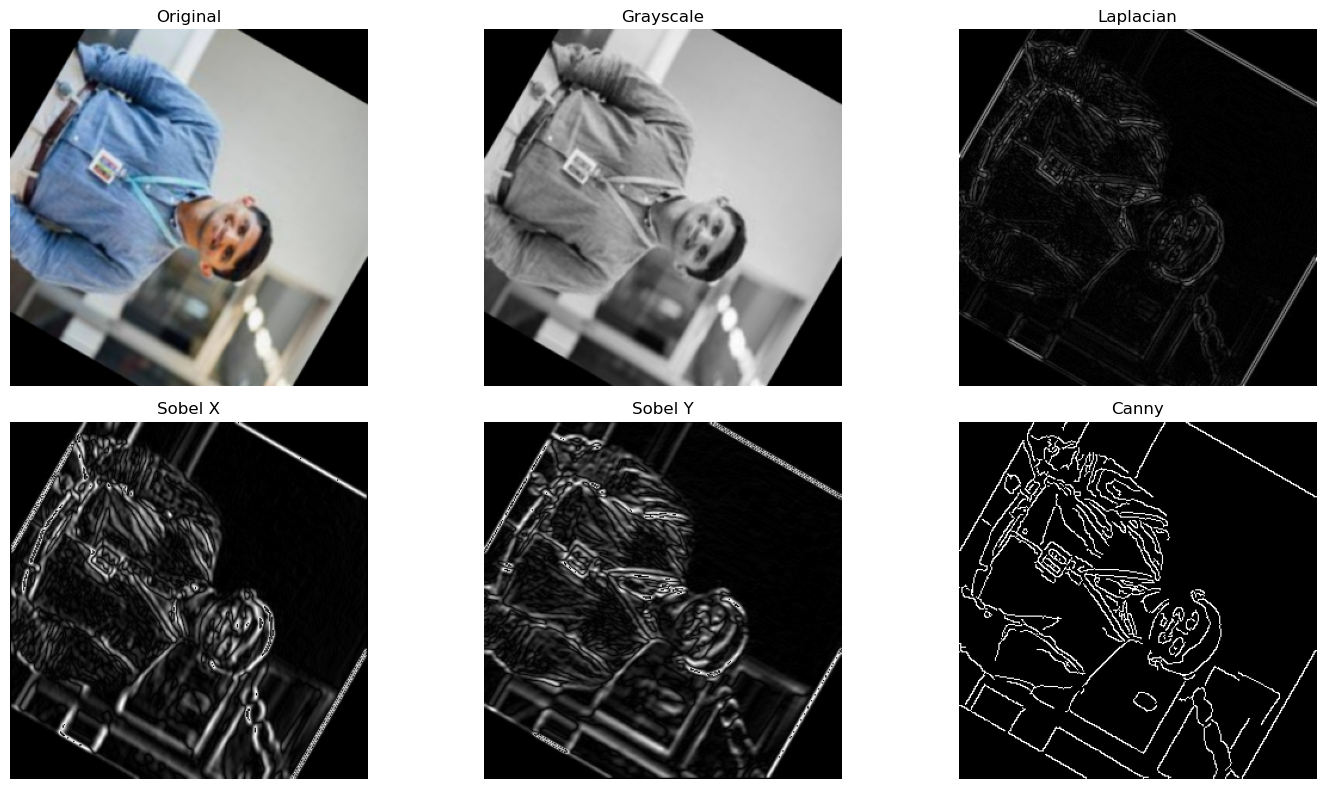

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================
# Read First Image
# ==========================
folder = r"C:\Users\dhanush\Downloads\id card detection\blur_dataset\wearing_id"

files = [f for f in os.listdir(folder)
         if f.lower().endswith((".jpg", ".jpeg", ".png"))]

image_path = os.path.join(folder, files[0])

img = cv2.imread(image_path)

# Resize
img = cv2.resize(img, (300,300))

# Convert BGR to RGB (for matplotlib)
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blur = cv2.GaussianBlur(gray, (3,3), 0)

# ==========================
# Edge Detection
# ==========================

# Laplacian
laplacian = cv2.Laplacian(blur, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# Sobel X
sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_x = np.uint8(np.absolute(sobel_x))

# Sobel Y
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel_y = np.uint8(np.absolute(sobel_y))

# Canny
canny = cv2.Canny(blur, 50, 150)

# ==========================
# Display
# ==========================

plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
import cv2
import os

# ==========================================
# Source Folder
# ==========================================
source_folder = r"C:\Users\dhanush\Downloads\id card detection\blur_dataset\wearing_id"

# ==========================================
# Destination Folder
# ==========================================
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\edge_dataset\wearing_id"

os.makedirs(destination_folder, exist_ok=True)

# ==========================================
# Apply Canny Edge Detection
# ==========================================
for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Canny Edge Detection
    edges = cv2.Canny(gray, 50, 150)

    # Save Edge Image
    cv2.imwrite(os.path.join(destination_folder, filename), edges)

print("Canny Edge Detection Applied Successfully for Wearing ID!")

Canny Edge Detection Applied Successfully for Wearing ID!


In [20]:
import cv2
import os

# ==========================================
# Source Folder
# ==========================================
source_folder = r"C:\Users\dhanush\Downloads\id card detection\blur_dataset\not_wearing_id"

# ==========================================
# Destination Folder
# ==========================================
destination_folder = r"C:\Users\dhanush\Downloads\id card detection\edge_dataset\not_wearing_id"

os.makedirs(destination_folder, exist_ok=True)

# ==========================================
# Apply Canny Edge Detection
# ==========================================
for filename in os.listdir(source_folder):

    path = os.path.join(source_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Canny Edge Detection
    edges = cv2.Canny(gray, 50, 150)

    # Save Edge Image
    cv2.imwrite(os.path.join(destination_folder, filename), edges)

print("Canny Edge Detection Applied Successfully for Not Wearing ID!")

Canny Edge Detection Applied Successfully for Not Wearing ID!


In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [22]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\blur_dataset",
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

Found 7248 files belonging to 2 classes.


In [23]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\split_dataset\validation",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 86 files belonging to 2 classes.


In [24]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\dhanush\Downloads\id card detection\split_dataset\test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 85 files belonging to 2 classes.


In [25]:
print(train_dataset.class_names)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

['not_wearing_id', 'wearing_id']
Train: 227
Validation: 3
Test: 3


In [26]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [27]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels)

(32, 224, 224, 3)
tf.Tensor([1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0], shape=(32,), dtype=int32)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
227/227 [==============================] - 115s 506ms/step - loss: 0.6841 - accuracy: 0.5537 - val_loss: 0.6750 - val_accuracy: 0.6512
Epoch 2/20
227/227 [==============================] - 122s 538ms/step - loss: 0.6679 - accuracy: 0.5785 - val_loss: 0.6699 - val_accuracy: 0.6395
Epoch 3/20
227/227 [==============================] - 128s 563ms/step - loss: 0.6302 - accuracy: 0.6362 - val_loss: 0.6428 - val_accuracy: 0.6977
Epoch 4/20
227/227 [==============================] - 107s 470ms/step - loss: 0.6033 - accuracy: 0.6565 - val_loss: 0.6175 - val_accuracy: 0.6977
Epoch 5/20
227/227 [==============================] - 113s 495ms/step - loss: 0.5637 - accuracy: 0.6980 - val_loss: 0.5799 - val_accuracy: 0.7093
Epoch 6/20
227/227 [==============================] - 105s 460ms/step - loss: 0.5224 - accuracy: 0.7299 - val_loss: 0.5908 - val_accuracy: 0.6512
Epoch 7/20
227/227 [==============================] - 106s 466ms/step - loss: 0.4967 - accuracy: 0.7536 - val_loss: 0.5743 -

1/1 [==============================] - 0s 38ms/step
Prediction : Not Wearing ID


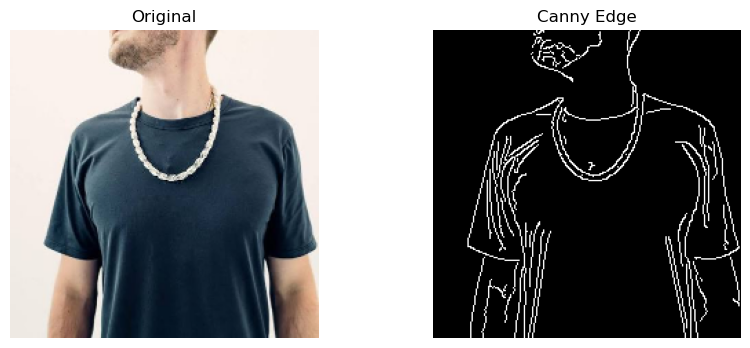

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
image_path = r"C:/Users/dhanush/Downloads/images (9).jpg"

img = cv2.imread(image_path)
img = cv2.resize(img, (224,224))

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussian Blur (recommended before Canny)
blur = cv2.GaussianBlur(gray, (3,3), 0)

# Canny Edge Detection
canny = cv2.Canny(blur, threshold1=50, threshold2=150)

# Convert edge image to 3 channels
edge = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

# Normalize
edge = edge.astype(np.float32) / 255.0

# Add Batch Dimension
edge = np.expand_dims(edge, axis=0)

# Prediction
prediction = model.predict(edge)

if prediction[0][0] > 0.5:
    print("Prediction : Not Wearing ID")
else:
    print("Prediction : Wearing ID")

# Display Images
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(canny, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.show()